In [33]:
!mkdir ./data_numpy

mkdir: ./data_numpy: File exists


In [34]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

warnings.filterwarnings('ignore')

DATA_PATH = './data_numpy'

df = pd.read_csv("./datasets/Base.csv")

# Data exploration

In [35]:
df.shape

(1000000, 32)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

In [37]:
df.head(5)

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


## Missing values

The paper mentions there are no missing values (meaning no `None`, `NaN`...)
but some column have a sentinel value to refer to missing values (so there are some...)

In [38]:
negative_values = df[df.select_dtypes(exclude=['object']) < 0]
print(negative_values.count())

fraud_bool                               0
income                                   0
name_email_similarity                    0
prev_address_months_count           712920
current_address_months_count          4254
customer_age                             0
days_since_request                       0
intended_balcon_amount              742523
payment_type                             0
zip_count_4w                             0
velocity_6h                             44
velocity_24h                             0
velocity_4w                              0
bank_branch_count_8w                     0
date_of_birth_distinct_emails_4w         0
employment_status                        0
credit_risk_score                    14445
email_is_free                            0
housing_status                           0
phone_home_valid                         0
phone_mobile_valid                       0
bank_months_count                   253635
has_other_cards                          0
proposed_cr

- **prev_address_months_count**: Number of months in previous registered
address of the applicant, i.e. the applicant’s previous residence, if applicable. Ranges
between [−1,380] months <u>**(-1 is a missing value)**</u>.

- **current_address_months_count**: Months in currently registered address of
the applicant. Ranges between [−1,429] months <u>**(-1 is a missing value)**</u>.

- **intended_balcon_amount**: Initial transferred amount for application.
Ranges between [−16,114] <u>**(negatives are missing values)**</u>.

- **credit_risk_score**: Internal score of application risk. Ranges between
[−191,389].

- **bank_months_count**: How old is previous account (if held) in months.
Ranges between [−1,32] months <u>**(-1 is a missing value)**</u>.

- **session_length_in_minutes**: Length of user session in banking website in
minutes. Ranges between [−1,107] minutes <u>**(-1 is a missing value)**</u>.

- **device_distinct_emails_8w**: Number of distinct emails in banking website from
the used device in last 8 weeks. Ranges between [−1,2] emails <u>**(-1 is a missing value)**</u>.

In [39]:
cols = [
    "prev_address_months_count",
    "current_address_months_count",
    "intended_balcon_amount", "bank_months_count",
    "session_length_in_minutes",
    "device_distinct_emails_8w"
]

df[df[cols] < 0] = np.nan
df

,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,NaN,25.0,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1.0,0,0
1,0,0.8,0.617426,NaN,89.0,20,0.010095,NaN,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1.0,0,0
2,0,0.8,0.996707,9.0,14.0,40,0.012316,NaN,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1.0,0,0
3,0,0.6,0.475100,11.0,14.0,30,0.006991,NaN,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1.0,0,0
4,0,0.9,0.842307,NaN,29.0,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,0,0.8,0.124690,NaN,143.0,30,0.051348,NaN,AB,530,...,0,1500.0,0,INTERNET,16.967770,other,0,1.0,0,7
999996,0,0.9,0.824544,NaN,193.0,30,0.009591,0.008307,AC,408,...,1,1000.0,0,INTERNET,1.504109,macintosh,0,1.0,0,7
999997,0,0.8,0.140891,NaN,202.0,10,0.059287,50.609995,AA,749,...,0,200.0,0,INTERNET,16.068595,other,0,1.0,0,7
999998,0,0.9,0.002480,52.0,3.0,30,0.023357,NaN,AB,707,...,0,200.0,0,INTERNET,1.378683,linux,1,1.0,0,7


We see that `prev_address_months_count` and `intended_balcon_amount` has around $74\%$ of values at `NaN`, so the 
best choice is to drop these columns

In [40]:
df = df.drop(columns=["prev_address_months_count",
             "intended_balcon_amount", "bank_months_count"])

In [41]:
df.isnull().sum()

fraud_bool                             0
income                                 0
name_email_similarity                  0
current_address_months_count        4254
customer_age                           0
days_since_request                     0
payment_type                           0
zip_count_4w                           0
velocity_6h                            0
velocity_24h                           0
velocity_4w                            0
bank_branch_count_8w                   0
date_of_birth_distinct_emails_4w       0
employment_status                      0
credit_risk_score                      0
email_is_free                          0
housing_status                         0
phone_home_valid                       0
phone_mobile_valid                     0
has_other_cards                        0
proposed_credit_limit                  0
foreign_request                        0
source                                 0
session_length_in_minutes           2015
device_os       

In [42]:
df = df.dropna(subset=["device_distinct_emails_8w",
               "session_length_in_minutes", "current_address_months_count"])

## Correlation between features

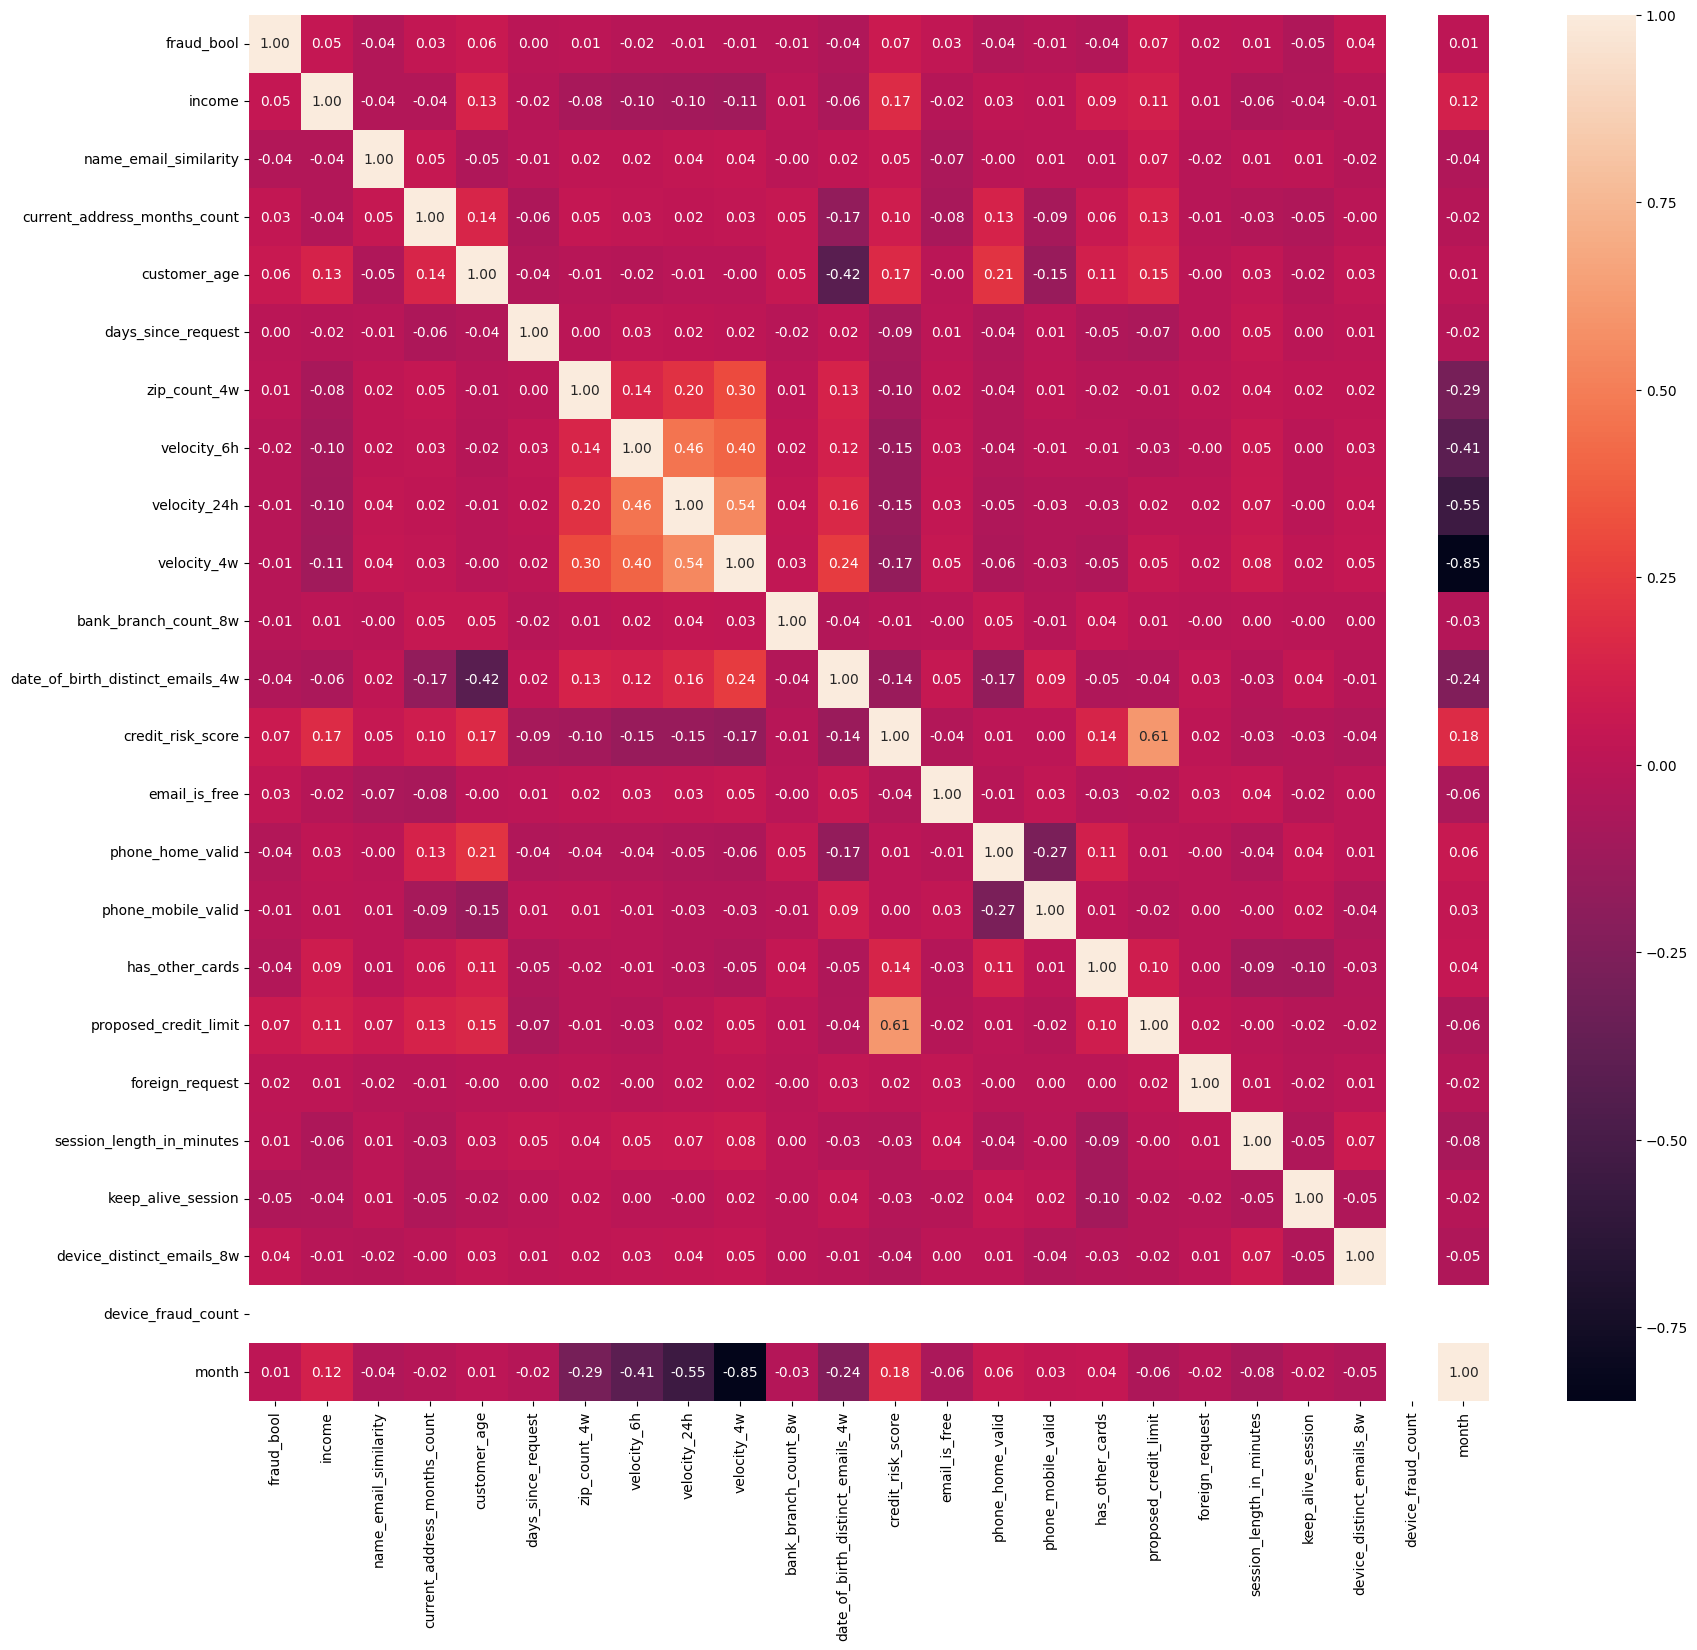

In [43]:
corr = df.select_dtypes(exclude=["object"]).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.show()

here, `device_fraud_count` looks wired. Thats because, for the `Base` variant, it has only one value.

In [44]:
print(df["device_fraud_count"].nunique(dropna=False))

1


so we can just drop it, as it's irrelevant.

In [45]:
df = df.drop(columns=["device_fraud_count"])

In general the data has a low correlation between each column, except some reasonable exception (e.g. the credit risk score with the proposed credit limit)

## Categorical data

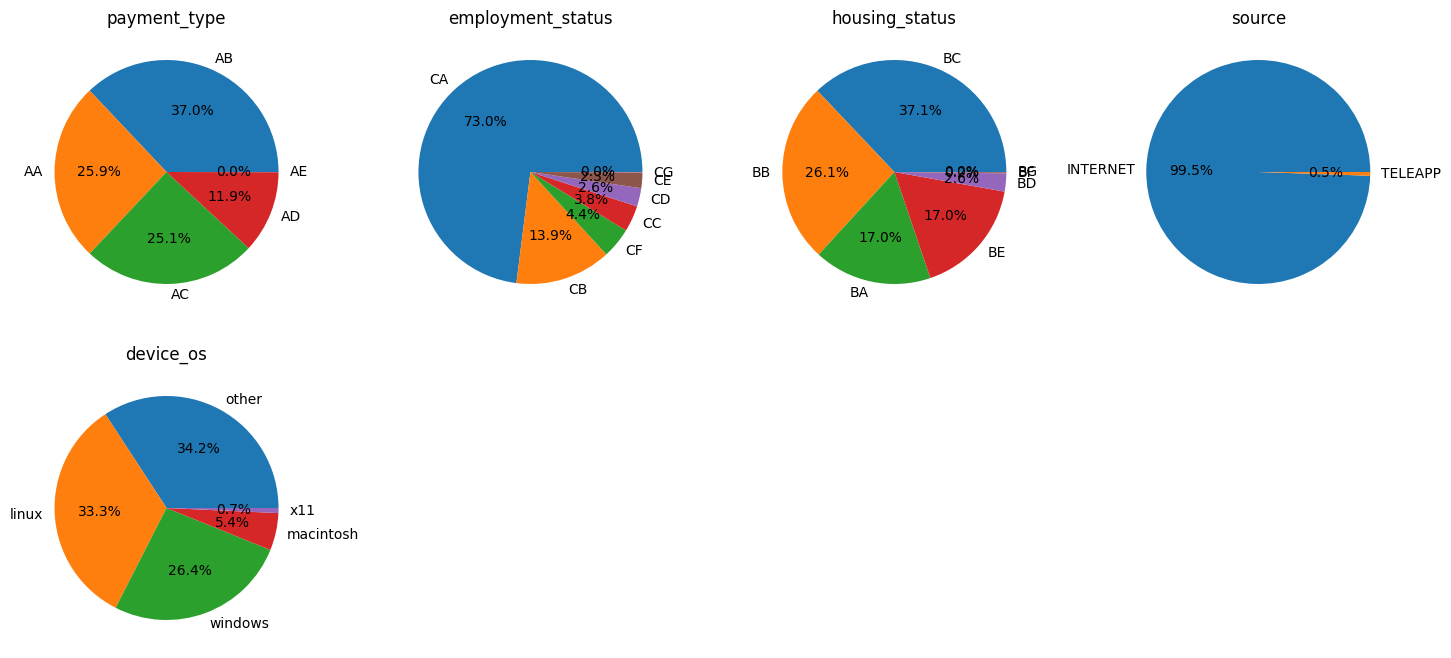

In [46]:
cat = df.select_dtypes(include=["object"])

n_cols = 4
n_rows = int(np.ceil(len(cat.columns) / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))

axs = axs.flatten()
for i, col in enumerate(cat.columns):
    count = cat[col].value_counts()
    axs[i].pie(count, labels=count.index, autopct='%1.1f%%')
    axs[i].set_title(f'{col}')

# remove unused subplots
for i in range(len(cat.columns), n_rows*n_cols):
    fig.delaxes(axs[i])

We can see that, for example, the column `source` has $\approx 99%$ of the values set to `INTERNET`, and 
less than $1%$ set to `TELEAPP`. The first tought could be to delete this column as it have
almost always the same value, but we have to remember that we have an highly imbalanced dataset and a potential
problem could be that all the $1%$ of the `TELEAPP` instances could be related to fraud applications.

## Labels distribution

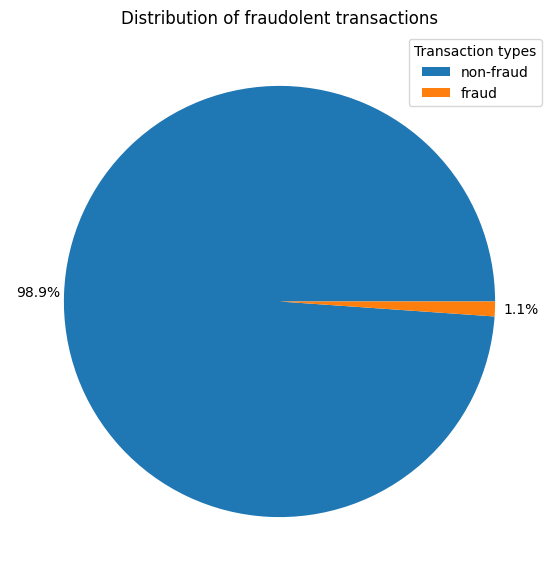

In [47]:
fraud_counts = df['fraud_bool'].value_counts()

plt.figure(figsize=(10, 7))
plt.pie(fraud_counts, autopct='%1.1f%%', pctdistance=1.12)
plt.title('Distribution of fraudolent transactions')
plt.legend(["non-fraud", "fraud"], title="Transaction types")
plt.show()

## Outliers

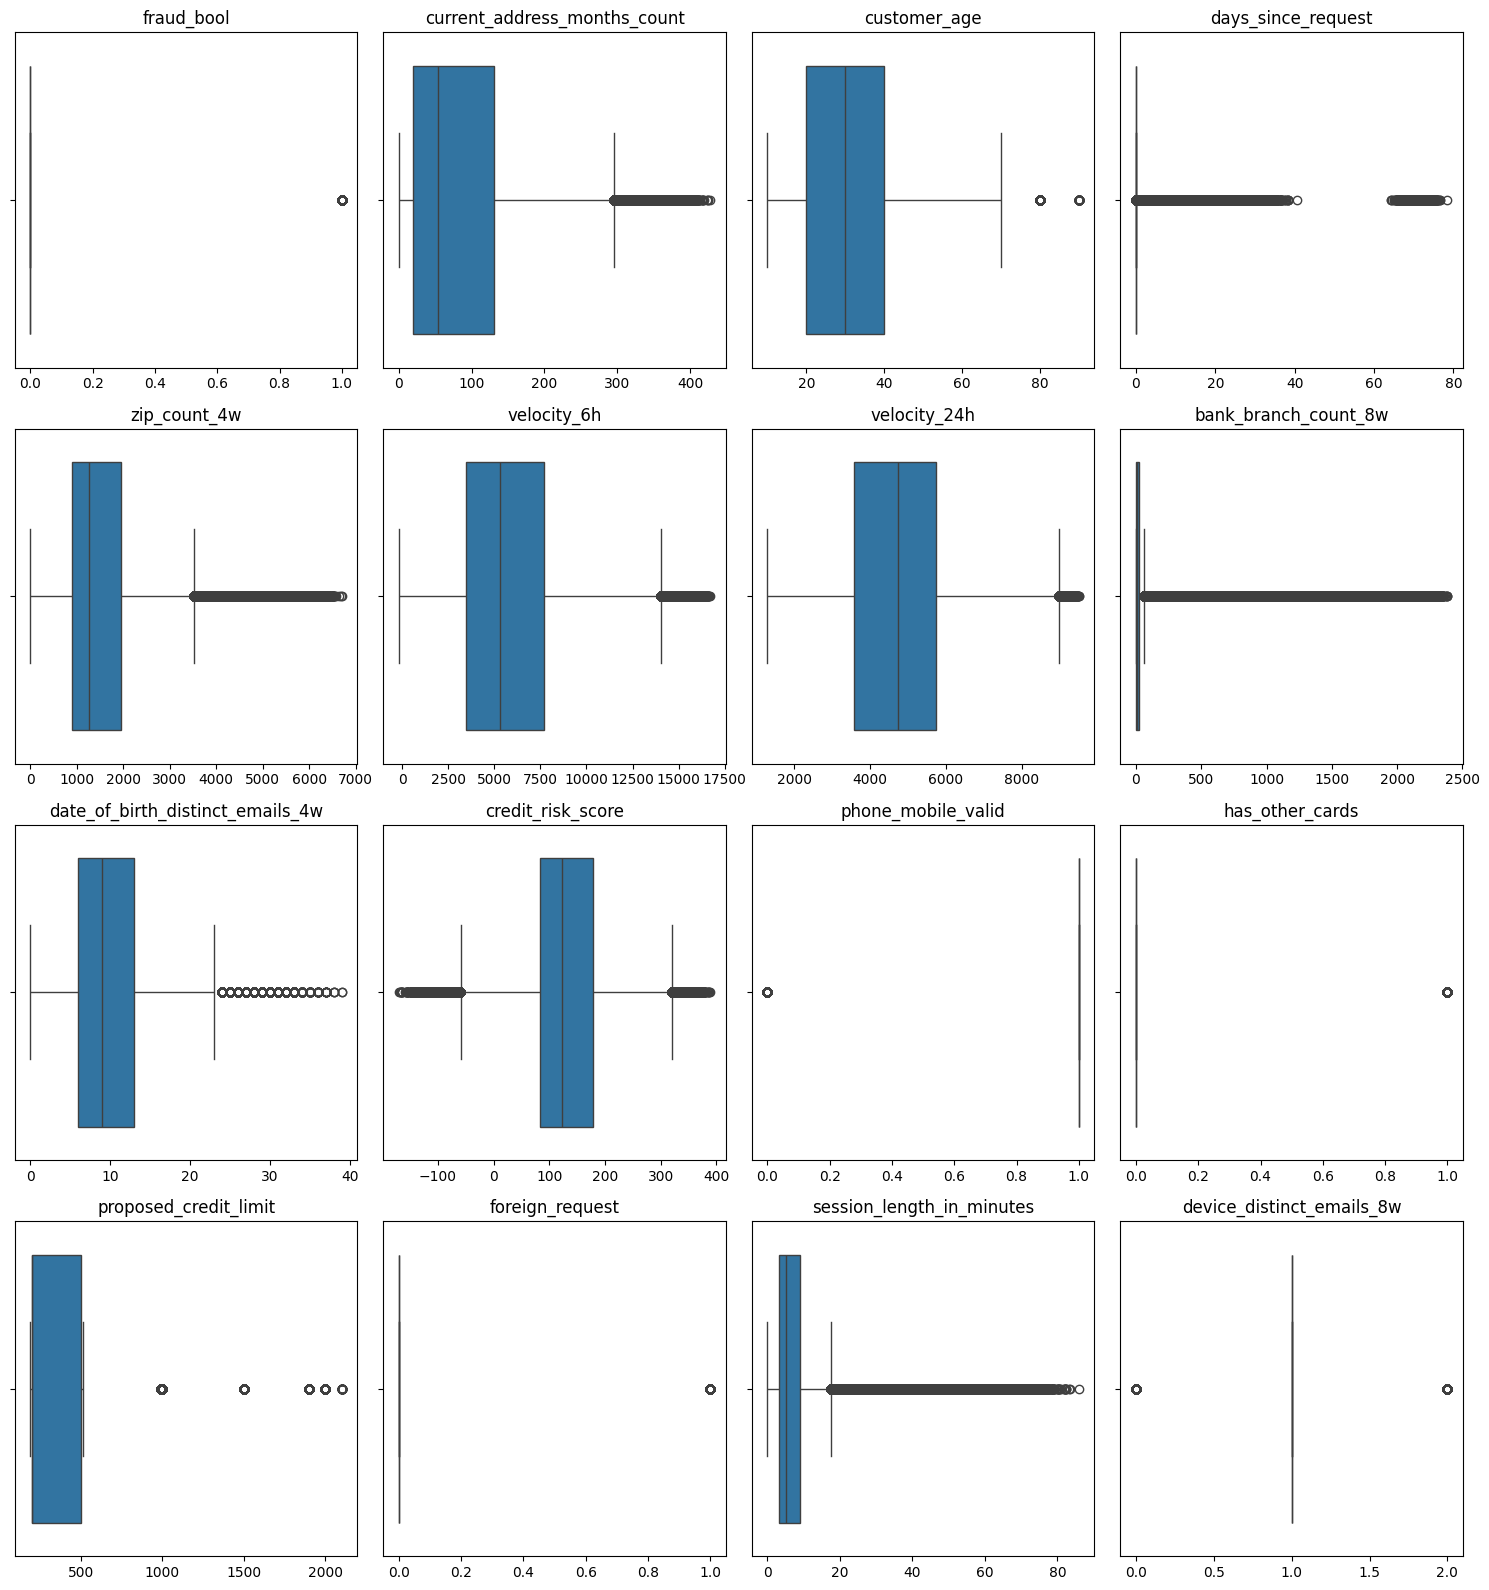

In [52]:
cols = df.select_dtypes(exclude=["object"]).columns

# get the column with at least one outlier
outlier_cols = []
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    if df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)].any(axis=None):
        outlier_cols.append(col)

n_cols = 4
n_rows = int(np.ceil(len(outlier_cols) / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))

axs = axs.flatten()
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axs[i])
    axs[i].set_title(f'{col}')
    axs[i].set_xlabel('')

plt.tight_layout()

## Train - Test split

In [17]:
!rm ./data_numpy/*

In [18]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler


def month_train_test_val_split(X: pd.DataFrame, y: pd.DataFrame):
    '''
    returns Xtr, Xval, Xte, ytr, yval, yte by assigning the first 5 months to training, 6th month to validation and 
    the last 2 to test
    '''
    return X[X["month"] < 5], X[X["month"] == 5], X[X["month"] > 5], y[X["month"] < 5], y[X["month"] == 5], y[X["month"] > 5]

In [19]:
X = df.drop(columns=["fraud_bool"])
y = pd.Series(df["fraud_bool"])

numeric_cols = X.select_dtypes(
    exclude=["object", "category"]).drop(columns=["month"]).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# convert "object" columns to "category"
X[categorical_cols] = X[categorical_cols].astype('category')

## Normalization

In [ ]:
scaler = MinMaxScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

Xtr_norm, Xval_norm, Xte_norm, ytr, yval, yte = month_train_test_val_split(
    X, y)

In [ ]:
Xtr_norm.to_csv(f"{DATA_PATH}/Xtr.csv", index=False)
Xval_norm.to_csv(f'{DATA_PATH}/Xval.csv', index=False)
Xte_norm.to_csv(f'{DATA_PATH}/Xte.csv', index=False)
ytr.to_csv(f'{DATA_PATH}/ytr.csv', index=False)
yval.to_csv(f'{DATA_PATH}/yval.csv', index=False)
yte.to_csv(f'{DATA_PATH}/yte.csv', index=False)

## Categorical data encoding

In [ ]:
X_encoded = X.copy()

encoder = OrdinalEncoder()
X_encoded[categorical_cols] = encoder.fit_transform(X[categorical_cols])

Xtr_encoded, Xval_encoded, Xte_encoded, _, _, _ = month_train_test_val_split(
    X_encoded, y)

In [ ]:
Xtr_encoded.to_csv(f"{DATA_PATH}/Xtr_encoded.csv", index=False)
Xval_encoded.to_csv(f'{DATA_PATH}/Xval_encoded.csv', index=False)
Xte_encoded.to_csv(f'{DATA_PATH}/Xte_encoded.csv', index=False)

## Oversampling

### No categorical data encoding

In [ ]:
from imblearn.over_sampling import SMOTENC

# get the corresponding index of the col
categorical_idxs = [X.columns.get_loc(col) for col in categorical_cols]
smotenc = SMOTENC(categorical_features=categorical_idxs)
X_resampled, y_resampled = smotenc.fit_resample(X, y)

Xtr_resampled, Xval_resampled, Xte_resampled, ytr, yval, yte = month_train_test_val_split(
    X_resampled, y_resampled)

In [ ]:
Xtr_resampled.to_csv(f"{DATA_PATH}/Xtr_resampled.csv", index=False)
Xval_resampled.to_csv(f'{DATA_PATH}/Xval_resampled.csv', index=False)
Xte_resampled.to_csv(f'{DATA_PATH}/Xte_resampled.csv', index=False)
ytr.to_csv(f'{DATA_PATH}/ytr_resampled.csv', index=False)
yval.to_csv(f'{DATA_PATH}/yval_resampled.csv', index=False)
yte.to_csv(f'{DATA_PATH}/yte_resampled.csv', index=False)

### Categorical data encoding

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_resampled_encoded, y_resampled = smote.fit_resample(X_encoded, y)

Xtr_resampled_encoded, Xval_resampled_encoded, Xte_resampled_encoded, ytr, yval, yte = month_train_test_val_split(
    X_resampled_encoded, y_resampled)

In [ ]:
Xtr_resampled_encoded.to_csv(
    f"{DATA_PATH}/Xtr_resampled_encoded.csv", index=False)
Xval_resampled_encoded.to_csv(
    f'{DATA_PATH}/Xval_resampled_encoded.csv', index=False)
Xte_resampled_encoded.to_csv(
    f'{DATA_PATH}/Xte_resampled_encoded.csv', index=False)
ytr.to_csv(f'{DATA_PATH}/ytr_resampled_encoded.csv', index=False)
yval.to_csv(f'{DATA_PATH}/yval_resampled_encoded.csv', index=False)
yte.to_csv(f'{DATA_PATH}/yte_resampled_encoded.csv', index=False)

## Appendix

- **`<data>.csv`**: normalized dataset, no categorical encoding
- **`<data>_encoded.csv`**: normalized dataset, ordinal encoding
- **`<data>_resampled.csv`**: normalized dataset, no categorical encoding, oversampled with SMOTE-NC
- **`<data>_resampled_encoded.csv`**: normalized dataset, ordinal encoding, oversampled with SMOTE